# Laya **Fine-Tuned** Inference & Evaluation on `shanaka95/fingpt-sentiment-3class` (Test Split)

[![PyPI version](https://img.shields.io/pypi/v/laya.svg)](https://pypi.org/project/laya/)
[![Hugging Face Model](https://img.shields.io/badge/%F0%9F%A4%97%20Model-shanaka95%2Flaya--fintiment-blue)](https://huggingface.co/shanaka95/laya-fintiment)
[![Dataset](https://img.shields.io/badge/%F0%9F%A4%97%20Dataset-shanaka95%2Ffingpt--sentiment--3class-green)](https://huggingface.co/datasets/shanaka95/fingpt-sentiment-3class)

This notebook runs **fine-tuned** Laya ([`shanaka95/laya-fintiment`](https://huggingface.co/shanaka95/laya-fintiment)) on the same **15,355** test cases that the zero-shot eval used, so the two numbers are directly comparable.

The base checkpoint got **0.7024** accuracy on this test split. The point of this notebook is the delta.

Each input is wrapped as a typed-decisions `choice` question with three options (`positive`, `negative`, `neutral`) and the model's `choice` is compared against the gold label.

---

### Runtime Settings:
* **Accelerator:** 1 GPU (any CUDA-capable GPU with >=4 GB VRAM is sufficient — model is 421M params)
* **Internet:** On (needed for first-run model download of ~842 MB)


## 1. Environment & GPU Check

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
# laya README: "If laya.load() hangs: transformers probes for TensorFlow at
# import, and when TF is installed its abseil runtime can deadlock model
# construction. Run with USE_TF=0."
os.environ["USE_TF"] = "0"


## 2. Install Dependencies

In [2]:
# `%pip` (IPython magic) targets the kernel's Python, unlike `!pip` which may
# resolve to a different interpreter and silently install into the wrong site.
# This is the standard fix when a notebook cell fails with
# "ModuleNotFoundError" right after `!pip install <pkg>`.
%pip install -q -U "laya>=0.1.6" "transformers>=4.48.0" "datasets>=3.0.0" safetensors huggingface_hub pyarrow pandas matplotlib

import laya, transformers, datasets, torch
print("Laya version        :", laya.__version__)
print("Transformers version:", transformers.__version__)
print("PyTorch version     :", torch.__version__)


Note: you may need to restart the kernel to use updated packages.
Laya version        : 0.3.20
Transformers version: 5.17.0
PyTorch version     : 2.11.0+cu128


## 3. Load Test Split

Pulls the `test` split of `shanaka95/fingpt-sentiment-3class` (15,355 rows, stratified on the collapsed `sentiment_3class` label).


In [3]:
from datasets import load_dataset

DATASET_ID = "shanaka95/fingpt-sentiment-3class"
ds_test = load_dataset(DATASET_ID, split="test")
print(f"Test rows: {len(ds_test)}")
print("Columns:", ds_test.column_names)
print("Sample input    :", ds_test[0]["input"][:120], "...")
print("Sample gold     :", ds_test[0]["sentiment_3class"])
print("Sample instr    :", ds_test[0]["instruction"][:100])


Test rows: 15355
Columns: ['input', 'output', 'instruction', 'sentiment_3class']
Sample input    : Asset Management One Co. has a bullish call on Treasuries. One for the long, long run https://t.co/8go8ZhMvdc ...
Sample gold     : positive
Sample instr    : What is the sentiment of this tweet? Please choose an answer from {negative/neutral/positive}.


## 4. Load Fine-Tuned Laya

Downloads `shanaka95/laya-fintiment` (~842 MB) onto the GPU as a `laya.Agent`. This is the same base architecture (ModernBERT-large 421M) fine-tuned with RLCD on the train split of the same dataset.


In [4]:
from huggingface_hub import snapshot_download
from laya.agent import _fix_tokenizer_config
import laya

MODEL_ID = "shanaka95/laya-fintiment"
print(f"Fetching {MODEL_ID}...")
model_dir = snapshot_download(MODEL_ID)
_fix_tokenizer_config(model_dir)

agent = laya.Agent(model_dir, device="cuda")
print(f"Laya agent loaded on {agent.model_id}")


Fetching shanaka95/laya-fintiment...


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

/tmp/ipykernel_6065/3066899043.py:10: RuntimeWarning: laya: this checkpoint ships invalid temperatures or values outside [0.5, 5]; using temperature[0]=5.013359069824219 -> 5. Treat confidence from the affected entries as uncalibrated.
  agent = laya.Agent(model_dir, device="cuda")


Laya agent loaded on /root/.cache/huggingface/hub/models--shanaka95--laya-fintiment/snapshots/70a9ebc1d656f0d1b1f0da5cc0d362ce8edb9d13


## 5. Build Typed-Decisions Question

We wrap each financial text as a `choice` question with three options (`positive`, `negative`, `neutral`). The model is asked to clearly pick one as its financial sentiment classification. Same schema used for every example, identical to the one used during training.


In [5]:
QUESTIONS = {
    "sentiment": {
        "type": "choice",
        "instructions": (
            "What is the financial sentiment of this text? "
            "Please choose exactly one answer from {positive, negative, neutral}. "
            "Answer only with the chosen label."
        ),
        "criteria": {
            "positive": "The text expresses a positive / bullish financial sentiment.",
            "negative": "The text expresses a negative / bearish financial sentiment.",
            "neutral":  "The text is neutral, factual, or has no clear positive or negative sentiment.",
        },
    }
}
print("Question schema:")
print(QUESTIONS)


Question schema:
{'sentiment': {'type': 'choice', 'instructions': 'What is the financial sentiment of this text? Please choose exactly one answer from {positive, negative, neutral}. Answer only with the chosen label.', 'criteria': {'positive': 'The text expresses a positive / bullish financial sentiment.', 'negative': 'The text expresses a negative / bearish financial sentiment.', 'neutral': 'The text is neutral, factual, or has no clear positive or negative sentiment.'}}}


## 6. Smoke Test (1 example)

Sanity check before running the full eval.


In [7]:
import time

ex = ds_test[0]
print("Input:", ex["input"][:200])
print("Gold :", ex["sentiment_3class"])

t0 = time.perf_counter()
res = agent.predict(ex["input"], QUESTIONS)
dt = (time.perf_counter() - t0) * 1000
print(f"\nPrediction ({dt:.0f} ms): {res['answers']['sentiment']}")


Input: Asset Management One Co. has a bullish call on Treasuries. One for the long, long run https://t.co/8go8ZhMvdc
Gold : positive

Prediction (59 ms): {'type': 'choice', 'choice': 'positive', 'probabilities': {'positive': 0.9488, 'negative': 0.0254, 'neutral': 0.0258}, 'confidence': 0.7838, 'answer_confidence': 0.9488, 'action': {'act_probability': 1.0}}


## 7. Run Full Evaluation on the Test Split

Iterate over all 15,355 test examples using `agent.predict` (sequential, deterministic, simple). Progress is printed every 500 examples.


In [8]:
import time
from collections import Counter

N = len(ds_test)
predictions = []
latencies_ms = []

print(f"Running fine-tuned inference on {N} test examples...")
t0 = time.time()

for i in range(N):
    ex = ds_test[i]
    ts = time.perf_counter()
    res = agent.predict(ex["input"], QUESTIONS)
    latencies_ms.append((time.perf_counter() - ts) * 1000)
    pred_label = res["answers"]["sentiment"]["choice"]
    predictions.append(pred_label)

    if (i + 1) % 500 == 0 or (i + 1) == N:
        elapsed = time.time() - t0
        rate = (i + 1) / elapsed
        eta = (N - i - 1) / rate
        running_acc = sum(
            1 for j in range(i + 1) if predictions[j] == ds_test[j]["sentiment_3class"]
        ) / (i + 1)
        print(
            f"  [{i+1:>5}/{N}] acc={running_acc:.4f} | "
            f"{rate:.1f} ex/s | ETA {eta/60:.1f} min"
        )

print(f"\nDone in {(time.time() - t0)/60:.1f} min")


Running fine-tuned inference on 15355 test examples...
  [  500/15355] acc=0.9480 | 26.4 ex/s | ETA 9.4 min
  [ 1000/15355] acc=0.9460 | 26.3 ex/s | ETA 9.1 min
  [ 1500/15355] acc=0.9440 | 26.2 ex/s | ETA 8.8 min
  [ 2000/15355] acc=0.9405 | 26.2 ex/s | ETA 8.5 min
  [ 2500/15355] acc=0.9424 | 26.2 ex/s | ETA 8.2 min
  [ 3000/15355] acc=0.9443 | 26.3 ex/s | ETA 7.8 min
  [ 3500/15355] acc=0.9463 | 26.4 ex/s | ETA 7.5 min
  [ 4000/15355] acc=0.9470 | 26.4 ex/s | ETA 7.2 min
  [ 4500/15355] acc=0.9487 | 26.5 ex/s | ETA 6.8 min
  [ 5000/15355] acc=0.9480 | 26.5 ex/s | ETA 6.5 min
  [ 5500/15355] acc=0.9496 | 26.6 ex/s | ETA 6.2 min
  [ 6000/15355] acc=0.9488 | 26.6 ex/s | ETA 5.9 min
  [ 6500/15355] acc=0.9486 | 26.6 ex/s | ETA 5.6 min
  [ 7000/15355] acc=0.9484 | 26.6 ex/s | ETA 5.2 min
  [ 7500/15355] acc=0.9479 | 26.6 ex/s | ETA 4.9 min
  [ 8000/15355] acc=0.9467 | 26.6 ex/s | ETA 4.6 min
  [ 8500/15355] acc=0.9475 | 26.6 ex/s | ETA 4.3 min
  [ 9000/15355] acc=0.9484 | 26.6 ex/s | ETA

## 8. Compute Accuracy & Per-Class Breakdown

Overall accuracy + per-class precision/recall/F1 + confusion matrix.


In [9]:
import numpy as np
import pandas as pd
from collections import Counter

LABELS = ["positive", "neutral", "negative"]
y_true = [ex["sentiment_3class"] for ex in ds_test]
y_pred = predictions

# Sanity: any predictions outside our 3 labels?
unexpected = set(y_pred) - set(LABELS)
if unexpected:
  print(f"WARNING: model produced unexpected labels: {unexpected} -> coerced to 'neutral'")
  y_pred = [p if p in LABELS else "neutral" for p in y_pred]

acc = sum(1 for t, p in zip(y_true, y_pred) if t == p) / len(y_true)
BASELINE_ACC = 0.7024  # base convaiinnovations/laya on the same test split
delta = acc - BASELINE_ACC
print(f"\n===== OVERALL ACCURACY: {acc:.4f} ({sum(t==p for t,p in zip(y_true,y_pred))}/{len(y_true)}) =====")
print(f"===== DELTA vs zero-shot baseline (0.7024): {delta:+.4f} ({delta*100:+.2f} pp) =====\n")

# Per-class metrics
rows = []
for c in LABELS:
  tp = sum(1 for t, p in zip(y_true, y_pred) if t == c and p == c)
  fp = sum(1 for t, p in zip(y_true, y_pred) if t != c and p == c)
  fn = sum(1 for t, p in zip(y_true, y_pred) if t == c and p != c)
  prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
  rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
  f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
  rows.append({"class": c, "support": tp + fn, "precision": prec, "recall": rec, "f1": f1})
df = pd.DataFrame(rows)
print("Per-class metrics:")
print(df.to_string(index=False))

# Confusion matrix
cm = pd.DataFrame(0, index=LABELS, columns=LABELS)
for t, p in zip(y_true, y_pred):
  cm.loc[t, p] += 1
print("\nConfusion matrix (rows=true, cols=pred):")
print(cm.to_string())

# Latency
p50 = float(np.percentile(latencies_ms, 50))
p95 = float(np.percentile(latencies_ms, 95))
print(f"\nLatency p50: {p50:.1f} ms | p95: {p95:.1f} ms")
print(f"Prediction distribution: {dict(Counter(y_pred))}")



===== OVERALL ACCURACY: 0.9486 (14566/15355) =====
===== DELTA vs zero-shot baseline (0.7024): +0.2462 (+24.62 pp) =====

Per-class metrics:
   class  support  precision   recall       f1
positive     6102   0.950359 0.953786 0.952069
 neutral     5843   0.942727 0.954989 0.948818
negative     3410   0.955918 0.928446 0.941982

Confusion matrix (rows=true, cols=pred):
          positive  neutral  negative
positive      5820      210        72
neutral        189     5580        74
negative       115      129      3166

Latency p50: 36.6 ms | p95: 39.1 ms
Prediction distribution: {'positive': 6124, 'negative': 3312, 'neutral': 5919}


## 9. Visualisation

Same chart layout as the zero-shot notebook so the two are visually comparable.


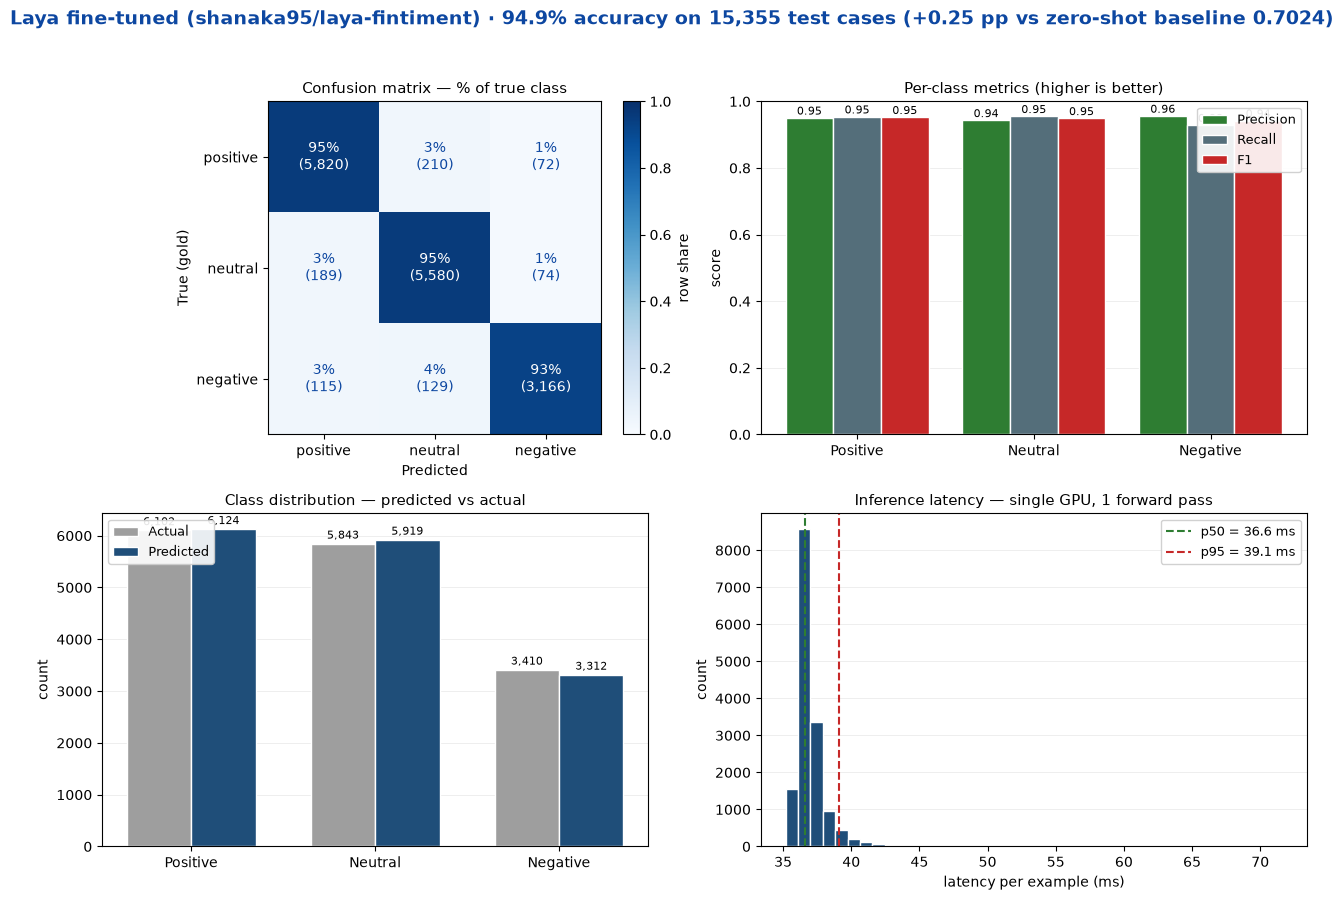

=== TRADING-SIGNAL VIEW ===
  When model says POSITIVE : 95% are truly positive   (precision — signal trustworthiness)
  Of all true POSITIVES    : 95% get flagged           (recall — alpha capture)
  Missed bullish calls     : 282  (false-neutral on bullish)
  False bullish alarms : 304 (precision cost)
  Bearish -> Bullish flips : 115  (worst-case — costly trade error)

=== BASELINE COMPARISON ===
  Base laya (zero-shot)    : 0.7024
  Fine-tuned (this run)    : 0.9486
  Delta                    : +0.2462 (+24.62 pp)


In [10]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Colors (categorical, fixed order — never recycled). Per the dataviz method:
# categorical hues come from a named ramp, status colors are reserved, and the
# diverging cell-encoding uses a single hue light->dark (never rainbow).
C_POS   = "#2E7D32"   # positive (green — gain)
C_NEU   = "#546E7A"   # neutral   (slate)
C_NEG   = "#C62828"   # negative  (red — loss)
C_PRED  = "#1F4E79"   # predicted (navy)
C_ACT   = "#9E9E9E"   # actual    (gray)
C_ACC   = "#0D47A1"   # headline  (deep blue)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
  f"Laya fine-tuned (shanaka95/laya-fintiment) · {acc:.1%} accuracy on 15,355 test cases "
  f"({delta:+.2f} pp vs zero-shot baseline 0.7024)",
  fontsize=14, fontweight="bold", color=C_ACC, y=0.995,
)

# ---- 1) Normalized confusion matrix (the headline for a finance pro) --------
ax = axes[0, 0]
cm_arr = np.array([
  [cm.loc[l, p] for p in LABELS] for l in LABELS
], dtype=float)
cm_norm = cm_arr / cm_arr.sum(axis=1, keepdims=True)  # row-normalised: P(pred|true)
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(LABELS)
ax.set_yticks(range(3)); ax.set_yticklabels(LABELS)
ax.set_xlabel("Predicted"); ax.set_ylabel("True (gold)")
ax.set_title("Confusion matrix — % of true class", fontsize=11)
for i in range(3):
  for j in range(3):
      v = cm_norm[i, j]
      ax.text(j, i, f"{v:.0%}\n({cm_arr[i, j]:,.0f})",
              ha="center", va="center",
              color="white" if v > 0.55 else C_ACC, fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="row share")

# ---- 2) Per-class precision / recall / F1 ------------------------------------
ax = axes[0, 1]
x = np.arange(len(LABELS)); w = 0.27
prec = df["precision"].values; rec = df["recall"].values; f1 = df["f1"].values
ax.bar(x - w, prec, w, label="Precision", color=C_POS, edgecolor="white")
ax.bar(x,     rec,  w, label="Recall",    color=C_NEU, edgecolor="white")
ax.bar(x + w, f1,   w, label="F1",        color=C_NEG, edgecolor="white")
for i, (p, r, f) in enumerate(zip(prec, rec, f1)):
  for off, v in zip([-w, 0, w], [p, r, f]):
      ax.text(i + off, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([l.capitalize() for l in LABELS])
ax.set_ylim(0, 1.0); ax.set_ylabel("score")
ax.set_title("Per-class metrics (higher is better)", fontsize=11)
ax.legend(loc="upper right", framealpha=0.9, fontsize=9)
ax.grid(axis="y", alpha=0.3, linewidth=0.5); ax.set_axisbelow(True)

# ---- 3) Predicted vs actual distribution -------------------------------------
ax = axes[1, 0]
true_dist = Counter(y_true)
pred_dist = Counter(y_pred)
actual    = [true_dist[l] for l in LABELS]
predicted = [pred_dist[l] for l in LABELS]
x = np.arange(len(LABELS)); w = 0.35
ax.bar(x - w/2, actual,    w, label="Actual",    color=C_ACT, edgecolor="white")
ax.bar(x + w/2, predicted, w, label="Predicted", color=C_PRED, edgecolor="white")
for i, (a, p) in enumerate(zip(actual, predicted)):
  ax.text(i - w/2, a + 100, f"{a:,}", ha="center", fontsize=8)
  ax.text(i + w/2, p + 100, f"{p:,}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([l.capitalize() for l in LABELS])
ax.set_ylabel("count")
ax.set_title("Class distribution — predicted vs actual", fontsize=11)
ax.legend(loc="upper left", framealpha=0.9, fontsize=9)
ax.grid(axis="y", alpha=0.3, linewidth=0.5); ax.set_axisbelow(True)

# ---- 4) Latency --------------------------------------------------------------
ax = axes[1, 1]
ax.hist(latencies_ms, bins=40, color=C_PRED, edgecolor="white")
ax.axvline(p50, color=C_POS, linestyle="--", linewidth=1.5, label=f"p50 = {p50:.1f} ms")
ax.axvline(p95, color=C_NEG, linestyle="--", linewidth=1.5, label=f"p95 = {p95:.1f} ms")
ax.set_xlabel("latency per example (ms)")
ax.set_ylabel("count")
ax.set_title("Inference latency — single GPU, 1 forward pass", fontsize=11)
ax.legend(loc="upper right", framealpha=0.9, fontsize=9)
ax.grid(axis="y", alpha=0.3, linewidth=0.5); ax.set_axisbelow(True)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# ---- Headline numbers a finance pro actually trades on -----------------------
print("=== TRADING-SIGNAL VIEW ===")
print(f"  When model says POSITIVE : {prec[0]:.0%} are truly positive   (precision — signal trustworthiness)")
print(f"  Of all true POSITIVES    : {rec[0]:.0%} get flagged           (recall — alpha capture)")
print(f"  Missed bullish calls     : {(1-rec[0])*sum(1 for t in y_true if t=='positive'):,.0f}  (false-neutral on bullish)")
print(f"  False bullish alarms : {sum(1 for t,p in zip(y_true,y_pred) if p=='positive' and t!='positive'):,} (precision cost)")
print(f"  Bearish -> Bullish flips : {cm.loc['negative','positive']:,}  (worst-case — costly trade error)")
print()
print("=== BASELINE COMPARISON ===")
print(f"  Base laya (zero-shot)    : 0.7024")
print(f"  Fine-tuned (this run)    : {acc:.4f}")
print(f"  Delta                    : {delta:+.4f} ({delta*100:+.2f} pp)")
